# Atividade de vendas no Brasil

## Entregável 1 Numpy

In [167]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [125]:
df = pd.read_csv('../../data/vendas_brasil_1.csv')

In [126]:
df.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


In [127]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  str    
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  str    
 3   canal_venda         37567 non-null  str    
 4   categoria           37617 non-null  str    
 5   produto             37617 non-null  str    
 6   vendedor            37577 non-null  str    
 7   fidelidade_cliente  37617 non-null  str    
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  prazo_entrega_d

In [128]:
# Criar arrays para algumas colunas
preco_unitario = np.array(df['preco_unitario'])

custo_unitario = np.array(df['custo_unitario'])

quantidade = np.array(df['quantidade'])

desconto = np.array(df['desconto_pct'])

receita_total = np.array(df['receita_total'])

frete = np.array(df['frete'])

avaliacao_clietne = np.array(df['avaliacao_cliente'])

prazo_entrega = np.array(df['prazo_entrega_dias'])

# analisado como 0 e 1
prazo_entrega = np.array(df['entrega_no_prazo'])

In [129]:
# Calculo com operações vetorizadas - sugeridas
valor_bruto = preco_unitario * quantidade
valor_desconto = valor_bruto * (desconto / 100)
custo_total = custo_unitario * quantidade
lucro_estimado = receita_total - custo_total

# Impacto do desconto no lucro
lucro_sem_desconto  =valor_bruto - custo_total
impacto_desconto_no_lucro = lucro_sem_desconto - lucro_estimado

In [130]:
# Criação de novas colunas
df['valor_bruto'] = valor_bruto
df['valor_desconto'] = valor_desconto 
df['custo_total'] = custo_total 
df['lucro_estimado'] = lucro_estimado

In [131]:
# Descobrir a distribuição de desconto pra saber o que é um desconto alto
print(np.percentile(desconto, [50, 75, 90]))

[ 9.  19.  24.4]


In [132]:
# Máscara: vendas com receita acima da media
receita_media = np.mean(receita_total)
mask_receita_alta = receita_total > receita_media

# Vendas com prejuízo (lucro negativo)
mask_prejuizo = lucro_estimado < 0

# Vendas com desconto alto (acima de x%)
mask_desconto_alto = desconto>24.4

In [133]:
# Aplicação das mascaras
print("Vendas com receita acima da média", np.sum(mask_receita_alta))
print("Vendas com prejuízo", np.sum(mask_prejuizo))
print("Vendas com desconto alto", np.sum(mask_desconto_alto))

Vendas com receita acima da média 9236
Vendas com prejuízo 2168
Vendas com desconto alto 3668


In [134]:
df[mask_prejuizo].head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,valor_bruto,valor_desconto,custo_total,lucro_estimado
8,2022-05-02,5,São Paulo,Site Web,Alimentação,Whey Protein,Bruno Souza,Prata,31.18,26.55,...,4.46,6.0,False,True,False,False,280.62,56.68524,238.95,-14.01
24,2022-07-11,7,Recife,App Mobile,Vestuário,Jaqueta,Ana Lima,Bronze,186.43,151.02,...,5.00,2.0,False,True,False,False,2610.02,662.94508,2114.28,-159.89
76,2023-07-10,7,Salvador,Loja Física,Livros,Machine Learning,Inês Nunes,Bronze,99.36,80.05,...,5.00,4.0,True,True,False,False,695.52,176.66208,560.35,-42.12
77,2022-06-11,6,Curitiba,Loja Física,Vestuário,Jaqueta,Inês Nunes,Bronze,102.96,85.35,...,4.03,14.0,False,False,False,False,720.72,139.81968,597.45,-17.00
101,2022-05-09,5,Manaus,Marketplace,Eletrônicos,Smartwatch,Bruno Souza,Ouro,980.24,776.73,...,5.00,19.0,False,True,False,True,11762.88,3058.34880,9320.76,-672.88


In [135]:
receita_media = np.mean(receita_total)
receita_maxima = np.max(receita_total)
receita_minima = np.min(receita_total)
lucro_medio = np.mean(lucro_estimado)
qtd_vendas_prejuizo = np.sum(mask_prejuizo)

print(f"Receita média: {receita_media:.2f}")
print(f"Maior receita: {receita_maxima:.2f}")
print(f"Menor receita: {receita_minima:.2f}")
print(f"Lucro médio: {lucro_medio:.2f}")
print(f"Quantidade de vendas com prejuízo: {qtd_vendas_prejuizo}")

Receita média: 1891.69
Maior receita: 58430.28
Menor receita: 3.70
Lucro médio: 513.19
Quantidade de vendas com prejuízo: 2168


### Conclusão

A análise das vendas reveou uma receita média de  R$ 1.891,69, mas existe uma grande variação entre as transações, tendo em vista a menor venda de R$ 3,70 e a maior que chegou a R$ 58.430,28. Esse intervalo amplo sugere uma distribuição assimétrica das vendas, o que justificaria por que apenas 24,6% delas apresentaram receita acima da média.

O lucro médio estimado foi de R$ 513,19, indicando rentabilidade positiva na maioria das operações. Contudo, foram identificadas 2.168 vendas com prejuízo, que podem possivelmente estar relacionadas a descontos elevados ou custos unitários próximos do preço de venda.

Por fim, foram definidos como "desconto alto" qualquer valor acima do percentil de 90 da distribuição, identificando 3.668 vendas nessa categoria. Esse recorte estatístico evita classificar desontos comuns como atípicos, focando apenas nos casos mais extremos.

## Entregável 2 Pandas

In [136]:
df.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,valor_bruto,valor_desconto,custo_total,lucro_estimado
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,4.92,5.0,False,True,False,False,7393.90,384.48280,5617.50,1315.98
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,4.98,19.0,True,False,False,False,937.40,5.62440,675.75,254.53
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,3.47,NaN,True,True,False,False,1065.54,7.45878,859.60,198.90
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,4.50,16.0,False,True,False,False,1604.46,9.62676,973.83,618.60
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,3.49,13.0,False,True,False,False,133.92,26.11440,107.25,0.39


In [137]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  str    
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  str    
 3   canal_venda         37567 non-null  str    
 4   categoria           37617 non-null  str    
 5   produto             37617 non-null  str    
 6   vendedor            37577 non-null  str    
 7   fidelidade_cliente  37617 non-null  str    
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  prazo_entrega_d

In [138]:
df.describe()

,mes,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,valor_bruto,valor_desconto,custo_total,lucro_estimado
count,37617.000000,37617.000000,37617.000000,37535.000000,37617.000000,37617.000000,37617.000000,35738.000000,34662.000000,36113.000000,37617.000000,37617.000000,37617.000000,37617.000000
mean,6.517691,253.214933,183.620999,22.714776,7.481750,9.494048,1891.688173,29.885737,3.912094,10.017113,1900.901827,180.368330,1378.501020,513.187153
std,3.439296,316.742367,231.376757,8.670213,4.322273,9.097484,2972.445759,24.765161,0.932256,5.477487,2917.039893,423.647566,2130.554022,1059.238617
min,1.000000,4.940000,3.010000,-0.570000,1.000000,0.000000,3.700000,3.750000,1.000000,1.000000,4.960000,0.000000,3.010000,-1462.710000
25%,4.000000,68.960000,49.550000,16.380000,4.000000,0.300000,364.280000,12.190000,3.490000,5.000000,375.650000,1.745800,270.080000,53.990000
50%,7.000000,111.300000,80.990000,22.700000,7.000000,9.000000,789.570000,22.250000,4.010000,10.000000,805.140000,37.580400,579.690000,171.760000
75%,9.000000,257.680000,186.570000,29.250000,11.000000,19.000000,1853.210000,39.480000,4.520000,15.000000,1854.930000,153.457500,1347.580000,471.060000
max,12.000000,9008.600000,6578.260000,44.270000,161.000000,26.000000,58430.280000,243.820000,5.000000,19.000000,63060.200000,15260.568400,46047.820000,19986.700000


In [139]:
df.shape

(37617, 25)

In [140]:
# Percentual de nulos
df.isna().sum()

data_venda               0
mes                      0
cidade                   0
canal_venda             50
categoria                0
produto                  0
vendedor                40
fidelidade_cliente       0
preco_unitario           0
custo_unitario           0
margem_pct              82
quantidade               0
desconto_pct             0
receita_total            0
frete                 1879
avaliacao_cliente     2955
prazo_entrega_dias    1504
devolucao                0
entrega_no_prazo         0
alta_temporada           0
flag_outlier_preco       0
valor_bruto              0
valor_desconto           0
custo_total              0
lucro_estimado           0
dtype: int64

O arquivo possui 37.617 linhas e 25 colunas (junto as 4 criadas na primeira etapa). Existem dados faltantes em 5 colunas: canal_venda(50),vendedor (40),margem_pct (82),frete (1879),avaliacao_cliente (2955), prazo_entrega_dias (1504).

As colunas númericas são preco_unitario, custo_unitario, margem_pct, quantidade, desconto_pct, receita_total, frete, avaliacao_cliente, prazo_entrega_dias e as booleanas, que também são numéricas em essência: devolucao, entrega_no_prazo, alta_temporada, flag_outlier_preco.

In [141]:
# Checando valores escritos de formas diferentes em colunas categóricas
for col in df.select_dtypes(include='str').columns:
        print(f"--- {col} ---")
        print(list(df[col].unique()))
        print()

--- data_venda ---
['2022-04-13', '2023-03-12', '2022-09-28', '2022-04-17', '2022-03-13', '2023-12-02', '2022-01-21', '2023-09-07', '2022-05-02', '2023-04-12', '2022-08-03', '2022-11-27', '2023-04-04', '2022-03-29', '2023-01-08', '2022-04-10', '26-10-2023', '2022-05-11', '2023-10-24', '2022-11-05', '2022-12-10', '2023-05-07', '2023-02-18', '2023-01-21', '2022-07-11', '2022-10-04', '2022-06-10', '2023-04-05', '2022-11-10', '2022-01-22', '2022-09-10', '2023-07-15', '2023-04-20', '2022-02-28', '2023-05-26', '2023-11-13', '2023-04-21', '2023-12-01', '2022-07-09', '2023-11-18', '2023-07-17', '2023-07-21', '2022-09-01', '2023-05-20', '2023-04-30', '2023-10-09', '2022-06-16', '2022-10-01', '2023-01-23', '2023-08-24', '2022-11-12', '2022-01-14', '2022-08-30', '2022-12-12', '2023-07-19', '2022-12-06', '2022-04-02', '2023-01-02', '2023-03-31', '2023-03-04', '2023-05-24', '2022-02-04', '2022-07-25', '2022-03-22', '2023-07-16', '2022-01-02', '2023-01-25', '2023-07-20', '2022-04-16', '2023-04-22', 

In [142]:
# Formatação da data
df['data_venda'] = pd.to_datetime(df['data_venda'], format='mixed', dayfirst=True)
df['data_venda'].isna().sum()

np.int64(0)

In [143]:
# Formatação texto
df['fidelidade_cliente'] = df['fidelidade_cliente'].str.strip().str.capitalize()
df['cidade'] = df['cidade'].str.strip().str.title()

# Dicionario de correção
mapa_cidades = {
    'Sp': 'São Paulo',
    'S. Paulo': 'São Paulo',
    'Sao Paulo': 'São Paulo',
    'Rj': 'Rio De Janeiro',
    'Bh': 'Belo Horizonte',
    'B. Horizonte': 'Belo Horizonte',
    'Curtiba': 'Curitiba',
    'Slavador': 'Salvador',
    'Rio': 'Rio De Janeiro',
}
df['cidade'] = df['cidade'].replace(mapa_cidades)
df['cidade'].unique()

<StringArray>
['Rio De Janeiro',         'Manaus',        'Goiânia',      'Fortaleza',
 'Belo Horizonte',         'Recife',      'São Paulo',   'Porto Alegre',
       'Salvador',       'Curitiba']
Length: 10, dtype: str

In [144]:
df['canal_venda'] = df['canal_venda'].str.strip().str.title()

mapa_canais = {
    'Siteweb': 'Site Web',
    'App Mobile': 'App Mobile',  # já ok depois do title()
    'Loja Fisica': 'Loja Física',
}

df['canal_venda'] = df['canal_venda'].replace(mapa_canais)

In [145]:
# Checagem da correção
df['data_venda'].dtype
df['data_venda'].isna().sum()

np.int64(0)

In [146]:
df['fidelidade_cliente'].unique()

<StringArray>
['Diamante', 'Bronze', 'Prata', 'Ouro']
Length: 4, dtype: str

A coluna cidade apresentava inconsistências de escrita, como variações de maiúsculas/minúsculas, espaços extras, siglas e erros de digitação (ex: 'Curtiba', 'Slavador'). Aplicamos strip() e title() para padronizar caixa e espaços, e um dicionário de mapeamento manual para corrigir siglas e erros de digitação, unificando todas as variações em um nome canônico por cidade. A coluna fidelidade_cliente teve tratamento semelhante, unificando variações de caixa (ex: 'OURO', 'ouro', 'Ouro') com capitalize(). A coluna data_venda apresentava múltiplos formatos de data, resolvidos com pd.to_datetime().

In [147]:
# Tratamento de dados faltantes

# Categoricas
df['canal_venda'] = df['canal_venda'].fillna(('Desconhecido'))
df['vendedor'] = df['vendedor'].fillna('Desconhecido')

# Numericas
df['margem_pct'] = df['margem_pct'].fillna(df['margem_pct'].median())
df['frete'] = df['frete'].fillna(df['frete'].median())
df['prazo_entrega_dias'] = df['prazo_entrega_dias'].fillna(df['prazo_entrega_dias'].median())

# avaliacao_cliente será mantido Nan

A avaliacao_cliente não foi alterada, visto que a informação de quais cliente não avaliaram ainda é relevante e causa um impacto diferente do que avaliar bem ou mal.

In [148]:
df['ano_venda'] = df['data_venda'].dt.year

In [149]:
df['lucro_total'] = df['receita_total'] - df['custo_total']

In [150]:
print(df['receita_total'].describe())

count    37617.000000
mean      1891.688173
std       2972.445759
min          3.700000
25%        364.280000
50%        789.570000
75%       1853.210000
max      58430.280000
Name: receita_total, dtype: float64


In [151]:
df['faixa_receita'] = df['receita_total'].apply(
    lambda x: 'Baixa' if x < np.percentile(receita_total, 25) else ('Média' if x < np.percentile(receita_total, 75) else 'Alta')
)

In [152]:
df[['receita_total','faixa_receita']].sample(10)

,receita_total,faixa_receita
24736,1013.60,Média
11655,288.69,Baixa
26090,659.18,Média
25259,1305.27,Média
27655,1437.82,Média
13381,2408.78,Alta
14112,744.06,Média
28730,581.71,Média
7623,7388.40,Alta
20883,266.15,Baixa


In [153]:
df['faixa_receita'].value_counts()

faixa_receita
Média    18809
Alta      9405
Baixa     9403
Name: count, dtype: int64

In [154]:
# Filros
filtro_receita_alta = df[df['receita_total'] > 5000]
filtro_devolucao = df[df['devolucao'] == True]
filtro_categoria = df[df['categoria'] == 'Eletrônicos']
filtro_combinado = df[(df['categoria'] == 'Eletrônicos') & (df['devolucao'] == True)]

print(f"Vendas com receita acima de R$ 5.000: {filtro_receita_alta.shape[0]}")
print(f"Vendas com devolução: {filtro_devolucao.shape[0]}")
print(f"Vendas de Eletrônicos: {filtro_categoria.shape[0]}")
print(f"Vendas de Eletrônicos com devolução: {filtro_combinado.shape[0]}")

Vendas com receita acima de R$ 5.000: 4004
Vendas com devolução: 3532
Vendas de Eletrônicos: 7515
Vendas de Eletrônicos com devolução: 691


Foram identificadas 4.004 vendas com receita acia de R$ 5.000, cerca de 10,6% do total de transações, provavelmente relacionadas a produtos de valor elevado ou compras em maior quantidade.

Foram encontradas 3.532 vendas com devolução registrada, o que representa aproximadamente 9,4% do total de transações. Já a categoria "Eletrônicos" apresentou 7.515 vendas no período analisado, o correspondente a cerca de 20% do total. No entanto, ao cruza categoria e devolução, encontramos apenas 691 vendas de Eletrônicos com devolução, o que representa 9,2% das vendas de Eltrônicos, uma taxa próxima da taxa geral de devolução (9,4%), sugerindo que a categoria não tem um problema de devolução desproporcional em relação ao restante das transações.

In [155]:
receita_por_categoria = df.groupby('categoria')['receita_total'].sum().sort_values(ascending=False)
receita_por_categoria

categoria
Eletrônicos    45017479.88
Esportes       11567480.75
Vestuário       6780473.93
Livros          4462597.93
Alimentação     3331601.51
Name: receita_total, dtype: float64

In [156]:
vendas_por_canal = df.groupby('canal_venda')['quantidade'].count().sort_values(ascending=False)
vendas_por_canal

canal_venda
Site Web        11346
App Mobile      11258
Loja Física      7498
Marketplace      5604
Televendas       1861
Desconhecido       50
Name: quantidade, dtype: int64

In [157]:
itens_por_canal = df.groupby('canal_venda')['quantidade'].sum().sort_values(ascending=False)
itens_por_canal

canal_venda
Site Web        85091
App Mobile      83839
Loja Física     56705
Marketplace     41707
Televendas      13726
Desconhecido      373
Name: quantidade, dtype: int64

In [158]:
receita_por_cidade = df.groupby('cidade')['receita_total'].sum().sort_values(ascending=False)
receita_por_cidade

cidade
Recife            7662241.79
Manaus            7459161.23
Fortaleza         7242081.82
Goiânia           7178113.69
Porto Alegre      7048428.17
Curitiba          6993175.07
Salvador          6918656.01
Belo Horizonte    6914747.61
Rio De Janeiro    6880176.34
São Paulo         6862852.27
Name: receita_total, dtype: float64

In [159]:
lucro_por_categoria = df.groupby('categoria')['lucro_total'].sum().sort_values(ascending=False)
lucro_por_categoria

categoria
Eletrônicos    12192275.55
Esportes        3133196.10
Vestuário       1849449.96
Livros          1225652.89
Alimentação      903986.63
Name: lucro_total, dtype: float64

In [160]:
resumo_categoria = df.groupby('categoria').agg(
    receita_total=('receita_total', 'sum'),
    lucro_total=('lucro_total', 'sum'),
    qtd_vendas=('quantidade', 'sum')
).sort_values('receita_total', ascending=False)

resumo_categoria

,receita_total,lucro_total,qtd_vendas
categoria,,,
Eletrônicos,45017479.88,12192275.55,56297
Esportes,11567480.75,3133196.10,57637
Vestuário,6780473.93,1849449.96,56284
Livros,4462597.93,1225652.89,55390
Alimentação,3331601.51,903986.63,55833


A categoria Eletrônicos lidera tanto em receita total (R$ 45.017.479,88) quanto em lucro total (R$ 12.192.275,55), muito à frente das demais. Esportes vem em segundo em ambas as métricas (R$ 11.567.480,75 em receita e R$ 3.133.196,10 em lucro). Isso é esperado dado o ticket médio mais alto de produtos eletrônicos comparado a Alimentação ou Livros, categorias de menor valor unitário.

No entanto, quanto as cidades, a receita total está bem distribuída, sem uma capial dominando isoladamente. Com Recife liderando com R$ 7.662.241,79, seguida por Manaus e por fim Fortaleza, o que indica ue a operação é esparsada geograficamente.

o canal Site Web lidera com 85.091 itens vendidos (11.346 transações), seguido de perto por App Mobile com 83.839 itens (11.258 transações). Loja Física aparece em terceiro (56.705 itens), e Televendas é o canal menos utilizado (13.726 itens). Os 373 registros "Desconhecido" representam os valores nulos tratados anteriormente.

In [162]:
regioes = pd.DataFrame({
    'cidade': ['São Paulo', 'Rio De Janeiro', 'Belo Horizonte', 'Curitiba', 
               'Porto Alegre', 'Salvador', 'Recife', 'Fortaleza', 
               'Manaus', 'Goiânia'],
    'regiao': ['Sudeste', 'Sudeste', 'Sudeste', 'Sul', 
               'Sul', 'Nordeste', 'Nordeste', 'Nordeste', 
               'Norte', 'Centro-Oeste']
})

regioes

,cidade,regiao
0,São Paulo,Sudeste
1,Rio De Janeiro,Sudeste
2,Belo Horizonte,Sudeste
3,Curitiba,Sul
4,Porto Alegre,Sul
5,Salvador,Nordeste
6,Recife,Nordeste
7,Fortaleza,Nordeste
8,Manaus,Norte
9,Goiânia,Centro-Oeste


In [163]:
df = df.merge(regioes, on='cidade', how='left')

In [165]:
receita_por_regiao = df.groupby('regiao')['receita_total'].sum().sort_values(ascending=False)
receita_por_regiao

regiao
Nordeste        21822979.62
Sudeste         20657776.22
Sul             14041603.24
Norte            7459161.23
Centro-Oeste     7178113.69
Name: receita_total, dtype: float64

In [166]:
vendas_por_regiao = df.groupby('regiao').size().sort_values(ascending=False)
vendas_por_regiao

regiao
Nordeste        11366
Sudeste         11098
Sul              7564
Norte            3804
Centro-Oeste     3785
dtype: int64

Ao relacionar as cidades às suas respectivas regiões, identificamos que o Nordeste concentra a maior receita total (R$ 21.822.979,62) e também o maior número de vendas (11.366), seguido de perto pelo Sudeste (R$ 20.657.776,22 em receita e 11.098 vendas). Isso é resultado direto de cada região concentrar 3 cidades no dataset (Recife, Fortaleza e Salvador no Nordeste; São Paulo, Rio de Janeiro e Belo Horizonte no Sudeste), enquanto Norte e Centro-Oeste têm apenas uma cidade cada (Manaus e Goiânia, respectivamente), o que naturalmente reduz seus totais. Vale notar que, olhando por cidade individual, a receita estava bem equilibrada. A concentração regional aqui reflete mais a quantidade de cidades por região do que um desempenho superior de fato.

## Entregável 3 Seaborn

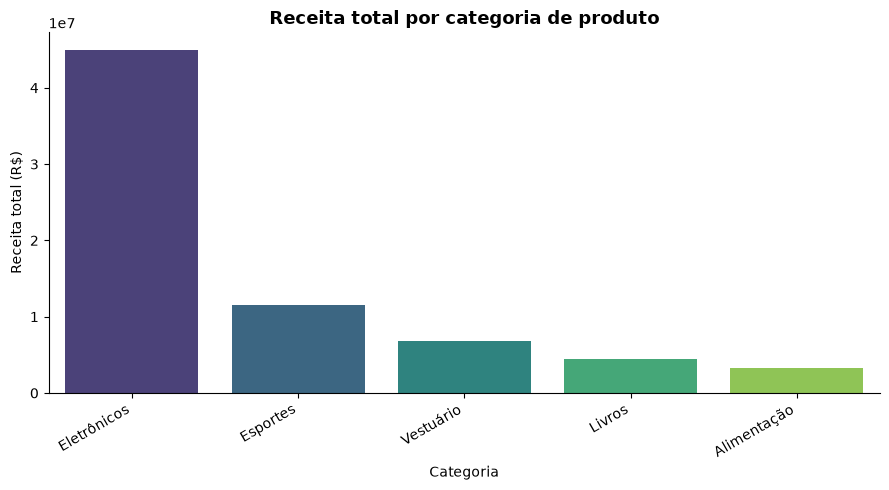

In [168]:
receita_categoria = df.groupby('categoria')['receita_total'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(9,5))
sns.barplot(data=receita_categoria, x='categoria', y='receita_total', hue='categoria', 
            palette='viridis', legend=False)
plt.title('Receita total por categoria de produto', fontsize=13, fontweight='bold')
plt.xlabel('Categoria')
plt.ylabel('Receita total (R$)')
plt.xticks(rotation=30, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

Eletrônicos domina de forma esmagadora, com receita muito acima de qualquer outra categoria - mais que o triplo de Esportes, a segunda colocada. Isso é coerente com o esperado, já que eletrônicos têm ticket unitário mais alto. Vestuário, Livros e Alimentação formam um grupo de menor receita, com queda gradual entre elas.

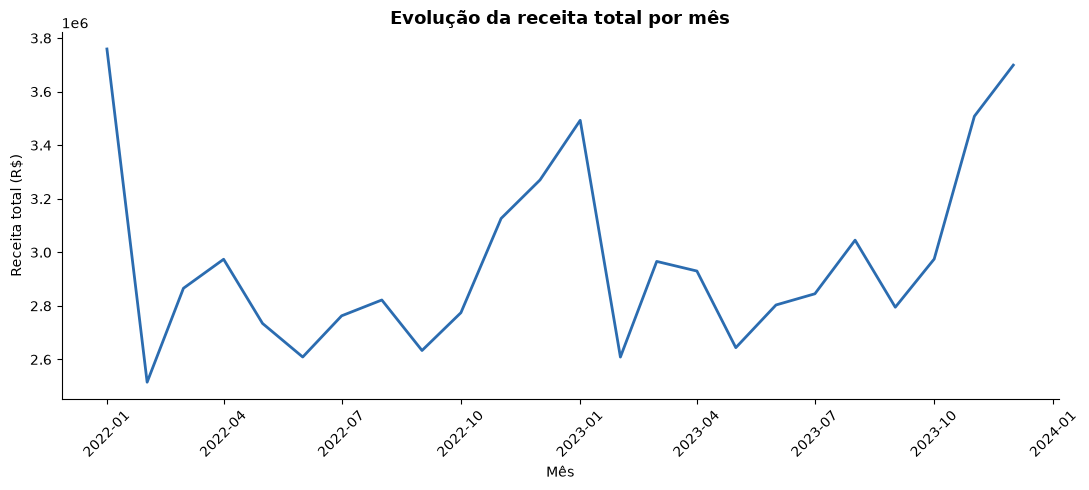

In [169]:
receita_temporal = df.groupby(df['data_venda'].dt.to_period('M'))['receita_total'].sum()
receita_temporal.index = receita_temporal.index.to_timestamp()

plt.figure(figsize=(11,5))
sns.lineplot(x=receita_temporal.index, y=receita_temporal.values, linewidth=2, color='#2b6cb0')
plt.title('Evolução da receita total por mês', fontsize=13, fontweight='bold')
plt.xlabel('Mês')
plt.ylabel('Receita total (R$)')
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()

O gráfico mostra um padrão sazonal bem definido: a receita despenca logo no início de cada ano (janeiro/fevereiro) e volta a subir de forma consistente até o fim do ano, atingindo os picos em dezembro - provavelmente puxado por datas como Black Friday e Natal. Esse ciclo se repete de forma quase idêntica em 2022 e 2023, o que reforça que é sazonalidade real, não ruído aleatório.

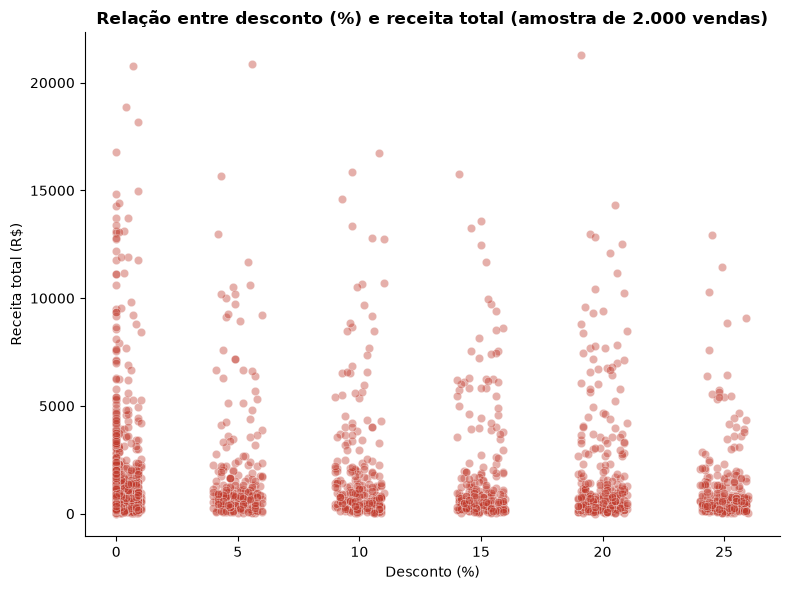

In [170]:
amostra = df.sample(2000, random_state=42)

plt.figure(figsize=(8,6))
sns.scatterplot(data=amostra, x='desconto_pct', y='receita_total', alpha=0.4, color='#c0392b')
plt.title('Relação entre desconto (%) e receita total (amostra de 2.000 vendas)', fontsize=12, fontweight='bold')
plt.xlabel('Desconto (%)')
plt.ylabel('Receita total (R$)')
sns.despine()
plt.tight_layout()
plt.show()

Não há uma tendência clara de queda ou subida da receita conforme o desconto aumenta - os pontos ficam espalhados de forma parecida em todas as faixas de desconto (0% a 25%). Isso confirma numericamente o que o heatmap abaixo mostra: correlação praticamente nula (-0.06) entre desconto e receita. Ou seja, dar mais desconto não está "puxando" vendas de maior valor nem prejudicando a receita de forma perceptível - o desconto parece ser aplicado de forma independente do valor da venda.

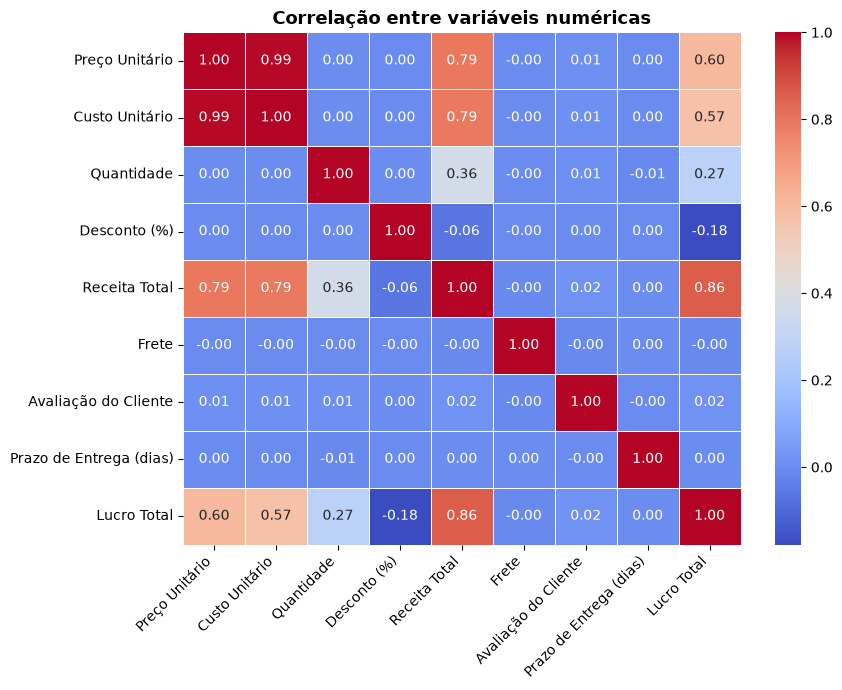

In [177]:
nomes_legiveis = {
    'preco_unitario': 'Preço Unitário',
    'custo_unitario': 'Custo Unitário',
    'quantidade': 'Quantidade',
    'desconto_pct': 'Desconto (%)',
    'receita_total': 'Receita Total',
    'frete': 'Frete',
    'avaliacao_cliente': 'Avaliação do Cliente',
    'prazo_entrega_dias': 'Prazo de Entrega (dias)',
    'lucro_total': 'Lucro Total'
}

correlacao_legivel = correlacao.rename(index=nomes_legiveis, columns=nomes_legiveis)

plt.figure(figsize=(9,7))
sns.heatmap(correlacao_legivel, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlação entre variáveis numéricas', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

O achado mais forte é a correlação quase perfeita entre preco_unitario e custo_unitario (0.99) - esperado, já que produtos mais caros tendem a ter custo proporcional mais alto. receita_total tem correlação forte com lucro_total (0.86) e moderada com preço/custo (0.79), o que faz sentido: quanto maior o valor da venda, maior tende a ser o lucro absoluto. Por outro lado, desconto_pct tem correlação fraca negativa com lucro_total (-0.18) - sugerindo que descontos mais agressivos de fato corroem um pouco o lucro, mesmo sem afetar a receita bruta. Variáveis logísticas (frete, avaliacao_cliente, prazo_entrega_dias) mostraram correlação próxima de zero com todas as outras, logo, satisfação do cliente e logística não parecem estar diretamente ligadas ao desempenho financeiro neste dataset.